# 04 - Modelos Alternativos
## APEAJAL - Pronóstico de Precios de Aguacate

**Objetivo:** Explorar una gama diversa de técnicas y enfoques con el fin de identificar el mejor deseméño para el problema de precicción de precios. Encontrar la configuración óptima que maximiza el rendimiento del modelo en la predicción de precios.

**Nombres y matrículas:**

  * José Antonio Gómez Mora | A01374459
  * Alejandro Chávez Campos | A01374974  
  * Laura Patricia Martínez Treviño | A01795967

**Número de Equipo:** 30

In [1]:
# Montar Google Drive (solo para Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive montado')
except:
    print('No estás en Colab, usando rutas locales')

Mounted at /content/drive
Google Drive montado


In [2]:
!pip install scikeras

In [3]:
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import ExtraTreesRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel
from scikeras.wrappers import KerasRegressor

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit

from keras.models import Sequential
from keras.layers import LSTM, Dense

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

import warnings
warnings.filterwarnings("ignore")

## 1. Carga y Exploración de Datos

In [4]:
DATA_PATH = '/content/drive/MyDrive/MNA/proyecto-integrador/processed2/dataset_completo.csv'
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df = df.set_index('date').sort_index()
print(f'Shape: {df.shape}')
print(f'Periodo: {df.index.min()} → {df.index.max()}')
df.head()

Shape: (97, 38)
Periodo: 2017-10-01 00:00:00 → 2025-12-01 00:00:00


,precio_promedio,cosecha_tons,embarques_tons,tipo_cambio,temp_min_c,temp_avg_c,temp_max_c,precipitation_mm,importaciones_kg,precio_importacion_usd,...,embarques_tons_log,importaciones_kg_log,precio_promedio_boxcox,tipo_cambio_boxcox,temp_avg_c_boxcox,temp_loca,temp_marcena,temp_normal,month_sin,month_cos
date,,,,,,,,,,,,,,,,,,,,,
2017-10-01,38.055,NaN,NaN,NaN,14.8,22.3,29.8,59.4,65462309.0,2.828279,...,0.0,17.996985,1.248926,NaN,2720.973388,False,False,False,-8.660254e-01,0.500000
2017-11-01,32.500,NaN,NaN,NaN,10.7,20.4,30.0,0.9,69112370.0,2.203476,...,0.0,18.051244,1.238492,NaN,2136.225003,False,False,False,-5.000000e-01,0.866025
2017-12-01,32.500,NaN,NaN,NaN,9.6,18.3,27.0,19.8,82046400.0,2.531162,...,0.0,18.222796,1.238492,NaN,1592.401787,False,False,False,-2.449294e-16,1.000000
2018-01-01,32.500,NaN,NaN,NaN,8.0,17.3,26.5,14.8,93731957.0,2.168603,...,0.0,18.355950,1.238492,NaN,1368.749137,False,False,True,5.000000e-01,0.866025
2018-02-01,32.500,NaN,NaN,NaN,11.0,19.7,28.5,16.2,80709833.0,2.205828,...,0.0,18.206371,1.238492,NaN,1943.405337,False,False,True,8.660254e-01,0.500000


In [5]:
# Variable objetivo
TARGET = 'precio_proximo_mes'
print(f'\nTarget: {TARGET}')
print(f'Registros con target válido: {df[TARGET].notna().sum()} de {len(df)}')
print(f'\nNulls por columna (top 15):')
print(df.isnull().sum().sort_values(ascending=False).head(15))


Target: precio_proximo_mes
Registros con target válido: 97 de 97

Nulls por columna (top 15):
cosecha_tons                70
embarques_tons              70
ratio_oferta_demanda        70
balance_oferta_demanda      70
precio_importacion_mxn      52
diferencial_precio_mx_us    52
tipo_cambio_boxcox          50
tipo_cambio                 50
temp_min_c                   3
temp_avg_c                   3
temp_precip_interaction      3
precio_lag3                  3
temp_max_c                   3
precipitation_mm             3
temp_avg_c_boxcox            3
dtype: int64


In [6]:
df["month"] = df.index.month
df["quarter"] = df.index.quarter
df["year"] = df.index.year

## 2. Preparación de Datos

In [7]:
# Features con buena cobertura (disponibles desde 2015)
FEATURES = [
    # Precio y lags
    'precio_promedio', 'precio_lag1', 'precio_lag2', 'precio_lag3',
    'precio_ma3', 'precio_ma6', 'precio_ma12', 'precio_std3',
    # Temporal
    'month', 'quarter', 'month_sin', 'month_cos',
    # Clima
    'temp_avg_c', 'precipitation_mm',
    # Importaciones
    'importaciones_kg',
    # Tipo de cambio
    'tipo_cambio',
]

def define_dfmodel():
  # Filtrar solo filas con target y features mínimos
  df_model = df[FEATURES + [TARGET]].dropna(subset=[TARGET, 'precio_lag3'])
  print(f'Registros para modelado: {len(df_model)}')
  print(f'Periodo: {df_model.index.min()} → {df_model.index.max()}')
  print(f'\nNulls restantes por columna:')
  print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

  return df_model

In [8]:
df_model = define_dfmodel()

Registros para modelado: 94
Periodo: 2018-01-01 00:00:00 → 2025-12-01 00:00:00

Nulls restantes por columna:
temp_avg_c           3
precipitation_mm     3
importaciones_kg     2
tipo_cambio         47
dtype: int64


In [9]:
df["month_sin"] = np.sin(2*np.pi*df.index.month/12)
df["month_cos"] = np.cos(2*np.pi*df.index.month/12)

## 3. Train/Test Split Temporal

In [10]:
# Imputar NaN restantes con forward fill + media
df_model = df_model.ffill().fillna(df_model.mean())

X = df_model[FEATURES]
y = df_model[TARGET]
print(f'X shape: {X.shape}, y shape: {y.shape}')
print(f'Nulls en X: {X.isnull().sum().sum()}, Nulls en y: {y.isnull().sum()}')

X shape: (94, 16), y shape: (94,)
Nulls en X: 0, Nulls en y: 0


### 4. Metricas

In [11]:
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return mae, rmse, mape

### 5. Definición de modelos

In [12]:
# SVR
svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR())
])

param_grid_svr = {
    "model__kernel":["rbf"],
    "model__C":[0.1,1,10,100],
    "model__epsilon":[0.01,0.1,0.2],
    "model__gamma":["scale","auto"]
}

In [13]:
# MLP
mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(max_iter=5000))
])

param_grid_mlp = {
    "model__hidden_layer_sizes":[(50,), (100,), (50,50)],
    "model__activation":["relu","tanh"],
    "model__alpha":[0.0001,0.001,0.01]
}

In [14]:

kernel = (
    1.0 * RBF(length_scale=10.0)
    + 1.0 * ExpSineSquared(length_scale=1.0, periodicity=12)
    + WhiteKernel(noise_level=1)
)

# Gaussian Process
gpr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True
    ))
])

param_grid_gpr = {
    "model__alpha":[1e-10,1e-5,1e-2]
}

In [15]:
models = {
"SVR": (
  svr_pipeline,
  param_grid_svr
),

"GaussianProcess": (
    gpr_pipeline,
    param_grid_gpr
),

"MLP": (
  mlp_pipeline,
  param_grid_mlp
),

"ExtraTrees": (
    ExtraTreesRegressor(),
    {
        "n_estimators":[100,300],
        "max_depth":[None,5,10],
        "min_samples_split":[2,5]
    }
)
}

### 6. TimeSeriesSplit

In [16]:
tscv = TimeSeriesSplit(
    n_splits=3,
    test_size=24  # 2 años
)

### 7. Evealuación

In [17]:
def evaluate_models(models, X, y):
    results = []

    for name, (model, params) in models.items():
        print(f"Entrenando modelo: {name}")

        grid = GridSearchCV(
            model,
            params,
            cv=tscv,
            scoring="neg_mean_absolute_error",
            n_jobs=-1
        )

        grid.fit(X, y)

        best_model = grid.best_estimator_

        mae_list = []
        rmse_list = []
        mape_list = []

        for train_idx, test_idx in tscv.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            best_model.fit(X_train, y_train)

            y_pred = best_model.predict(X_test)

            mae, rmse, mape = compute_metrics(y_test, y_pred)

            mae_list.append(mae)
            rmse_list.append(rmse)
            mape_list.append(mape)

        results.append({
            "Model": name,
            "MAE_mean": np.mean(mae_list),
            "RMSE_mean": np.mean(rmse_list),
            "MAPE_mean": np.mean(mape_list),
            "MAPE_std": np.std(mape_list),
            "Best_params": grid.best_params_

        })

    return pd.DataFrame(results)

### 8. Ejecutar pipeline

In [18]:
results = evaluate_models(models, X, y)

Entrenando modelo: SVR
Entrenando modelo: GaussianProcess
Entrenando modelo: MLP
Entrenando modelo: ExtraTrees


### 9. Tabla comparativa

In [19]:
results = results.sort_values("MAPE_mean")

print(results)

             Model   MAE_mean  RMSE_mean  MAPE_mean   MAPE_std  \
3       ExtraTrees   8.469999  11.004023  16.686261   6.359774   
1  GaussianProcess   9.309761  11.486433  17.373433   8.341823   
0              SVR   9.705420  12.457800  17.808685   7.711130   
2              MLP  13.160864  17.129464  30.433937  13.176115   

                                         Best_params  
3  {'max_depth': None, 'min_samples_split': 5, 'n...  
1                             {'model__alpha': 0.01}  
0  {'model__C': 10, 'model__epsilon': 0.2, 'model...  
2  {'model__activation': 'relu', 'model__alpha': ...  


### 10. Gráfica comparativa

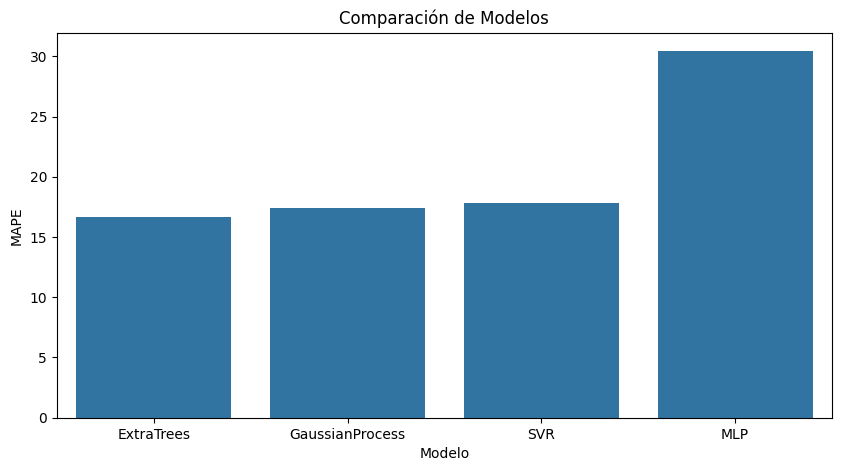

In [20]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Model",
    y="MAPE_mean"
)

plt.title("Comparación de Modelos")
plt.ylabel("MAPE")
plt.xlabel("Modelo")

plt.show()

### 11. LSTM

#### 11.1 Secuencias

#### 11.2 LSTM

In [21]:

# 1. Función para crear ventanas
def create_sequences(X, y, window):

    Xs, ys = [], []

    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])

    return np.array(Xs), np.array(ys)


# 2. Escalar datos
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1)).flatten()

# 3. Crear secuencias
window = 36

X_seq, y_seq = create_sequences(X_scaled, y_scaled, window)



# 4. Modelo LSTM
def build_lstm(input_shape):

    model = Sequential()

    model.add(LSTM(128, return_sequences=True, input_shape=input_shape))
    model.add(LSTM(64, return_sequences=True))
    model.add(LSTM(32))

    model.add(Dense(16, activation="relu"))
    model.add(Dense(1))

    model.compile(
        optimizer="adam",
        loss="mse"
    )
    return model


# 5. Wrapper para sklearn
lstm_model = KerasRegressor(
    model=build_lstm,
    model__input_shape=(window, X.shape[1]),
    epochs=100,
    batch_size=32,
    verbose=0
)

# 6. Grid de parámetros
param_grid_lstm = {
    "epochs": [100, 200],
    "batch_size": [16, 32]
}

In [22]:
models["LSTM"] = (
    lstm_model,
    param_grid_lstm
)

In [23]:
tscv = TimeSeriesSplit(n_splits=3)

### 12. Visualizar predicciones

In [24]:

def visualize_forecasting_models(models, X, y, tscv):

    for name, (model, params) in models.items():

        print(f"\nModelo: {name}")

        is_lstm = "LSTM" in name.upper()

        if not is_lstm:

            grid = GridSearchCV(
                model,
                params,
                cv=tscv,
                scoring="neg_mean_absolute_error",
                n_jobs=-1
            )

            grid.fit(X, y)
            best_model = grid.best_estimator_

            preds = np.full(len(y), np.nan)
            test_windows = []

            for train_idx, test_idx in tscv.split(X):

                X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
                y_train = y.iloc[train_idx]

                best_model.fit(X_train, y_train)
                preds[test_idx] = best_model.predict(X_test)

                test_windows.append((test_idx[0], test_idx[-1]))

        else:

            print("Usando secuencias para LSTM")

            X_seq, y_seq = create_sequences(X.values, y.values, window)

            preds = np.full(len(y_seq), np.nan)
            test_windows = []

            for train_idx, test_idx in tscv.split(X_seq):

                X_train, X_test = X_seq[train_idx], X_seq[test_idx]
                y_train = y_seq[train_idx]

                model.fit(X_train, y_train)

                preds[test_idx] = model.predict(X_test).flatten()

                test_windows.append((test_idx[0], test_idx[-1]))

            y = y.iloc[window:]
            preds = preds

        residuals = y.values - preds

        fig = plt.figure(figsize=(20,12))

        # -------- PREDICCION --------
        ax1 = plt.subplot(3,1,1)

        ax1.plot(y.index, y.values, label="Real", linewidth=3)
        ax1.plot(y.index, preds, label="Predicción")

        for start, end in test_windows:
            ax1.axvspan(
                y.index[start],
                y.index[end],
                alpha=0.15
            )

        ax1.set_title(f"Predicción vs Real — {name}")

        ax1.grid(True, linestyle="--", alpha=0.6)

        ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

        for label in ax1.get_xticklabels():
            label.set_rotation(90)

        ax1.legend()

        # -------- RESIDUALES --------
        ax2 = plt.subplot(3,1,2)

        ax2.plot(y.index, residuals)

        ax2.axhline(0, linestyle="--")

        ax2.set_title("Errores (Residuales)")

        ax2.grid(True, linestyle="--", alpha=0.6)

        ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

        for label in ax2.get_xticklabels():
            label.set_rotation(90)

       # ---------------- METRICAS ----------------
        mask = ~np.isnan(preds)

        y_true = y.values[mask]
        y_pred = preds[mask]

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        mape_std = np.std(np.abs((y_true - y_pred) / y_true) * 100)

        print(f"MAE : {mae:.2f}")
        print(f"RMSE: {rmse:.2f}")
        print(f"MAPE: {mape:.2f}%")
        print(f"MAPE Std: {mape_std:.2f}")

        # -------- HISTOGRAMA --------
        ax3 = plt.subplot(3,1,3)

        clean_residuals = residuals[~np.isnan(residuals)]

        ax3.hist(clean_residuals, bins=30)

        ax3.set_title("Distribución de errores")

        ax3.grid(True, linestyle="--", alpha=0.6)

        plt.tight_layout()

        plt.show()


Modelo: SVR
MAE : 9.35
RMSE: 14.58
MAPE: 16.64%
MAPE Std: 13.88


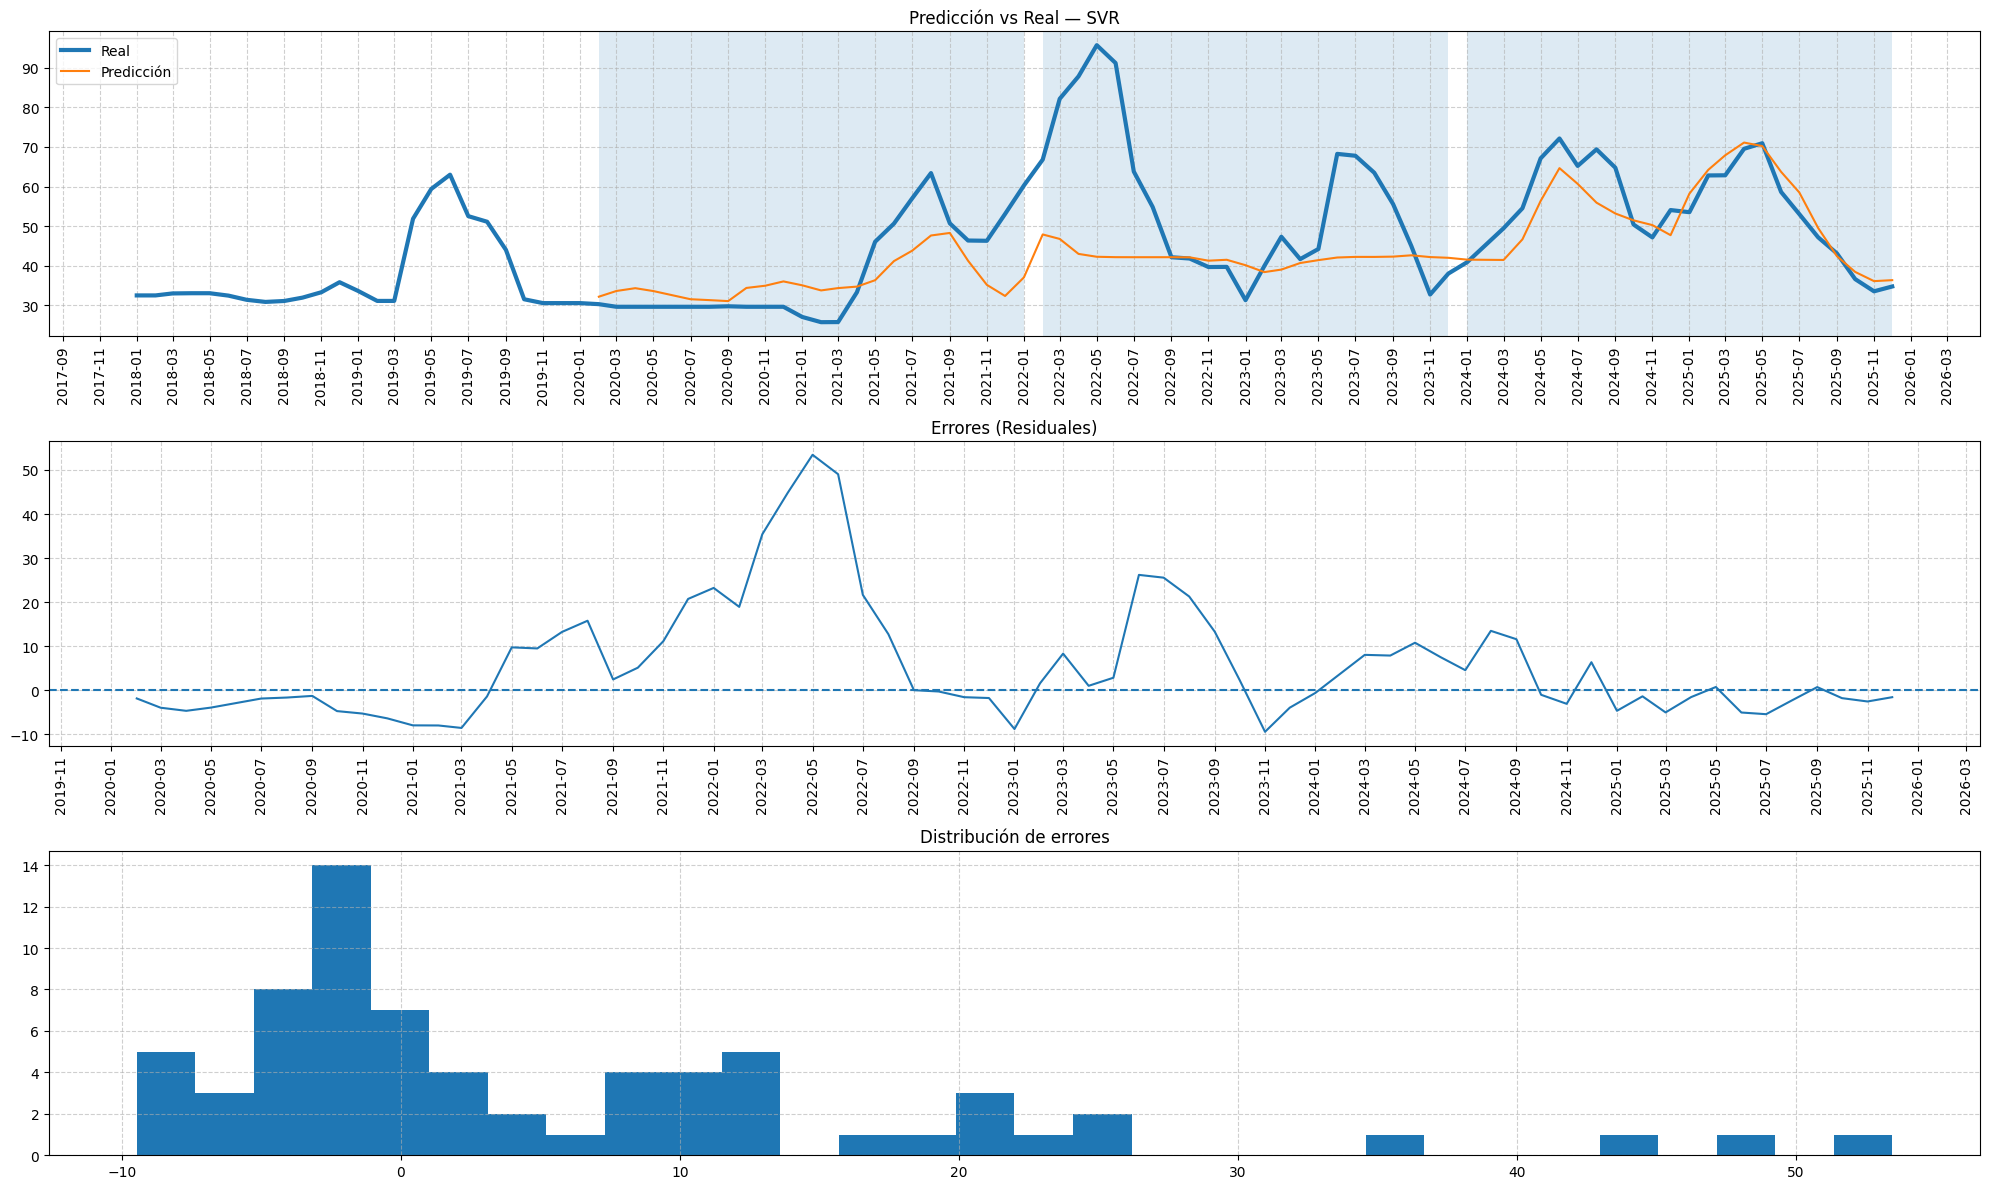


Modelo: GaussianProcess
MAE : 9.11
RMSE: 13.64
MAPE: 16.59%
MAPE Std: 13.00


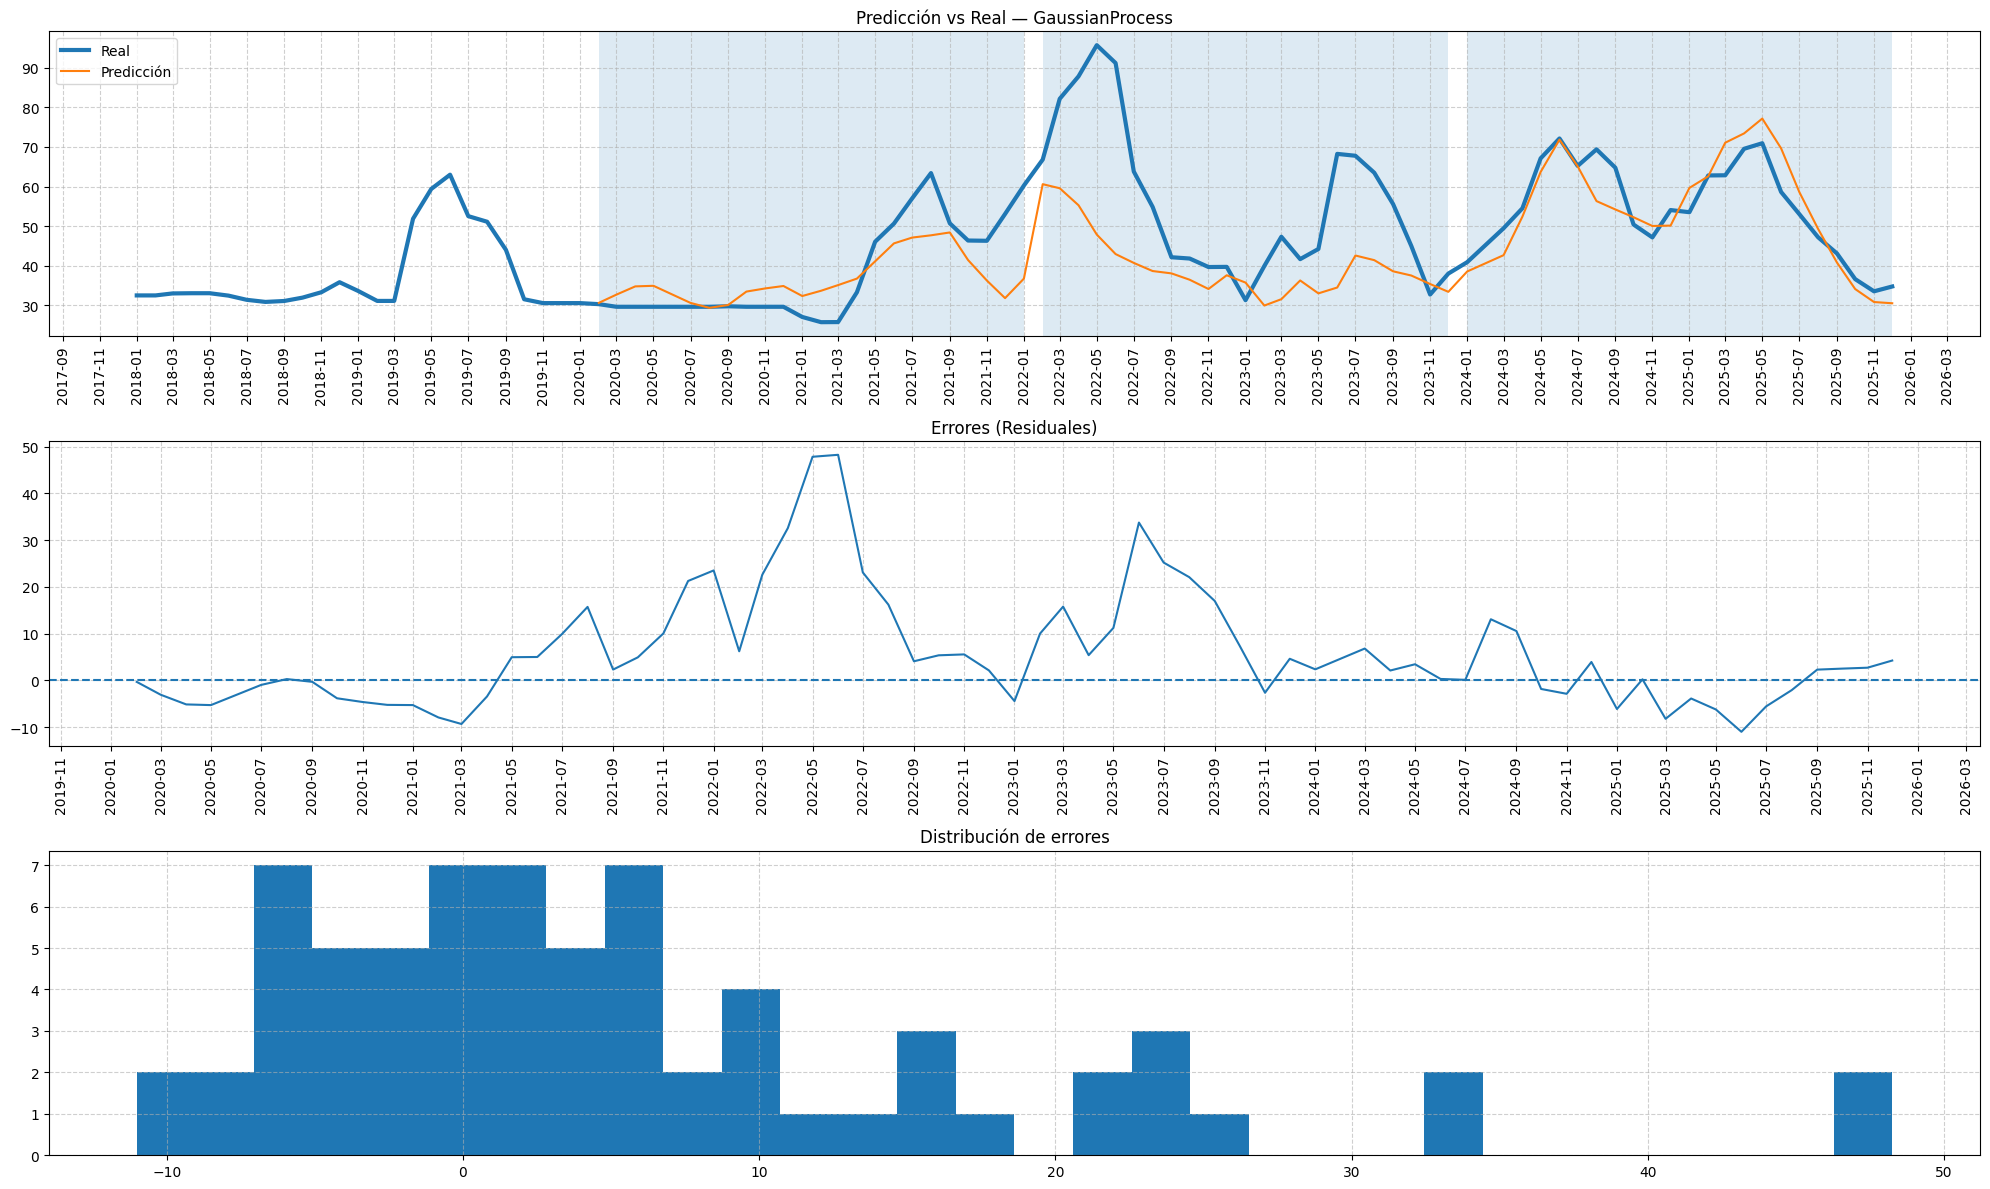


Modelo: MLP
MAE : 13.97
RMSE: 19.18
MAPE: 31.67%
MAPE Std: 34.88


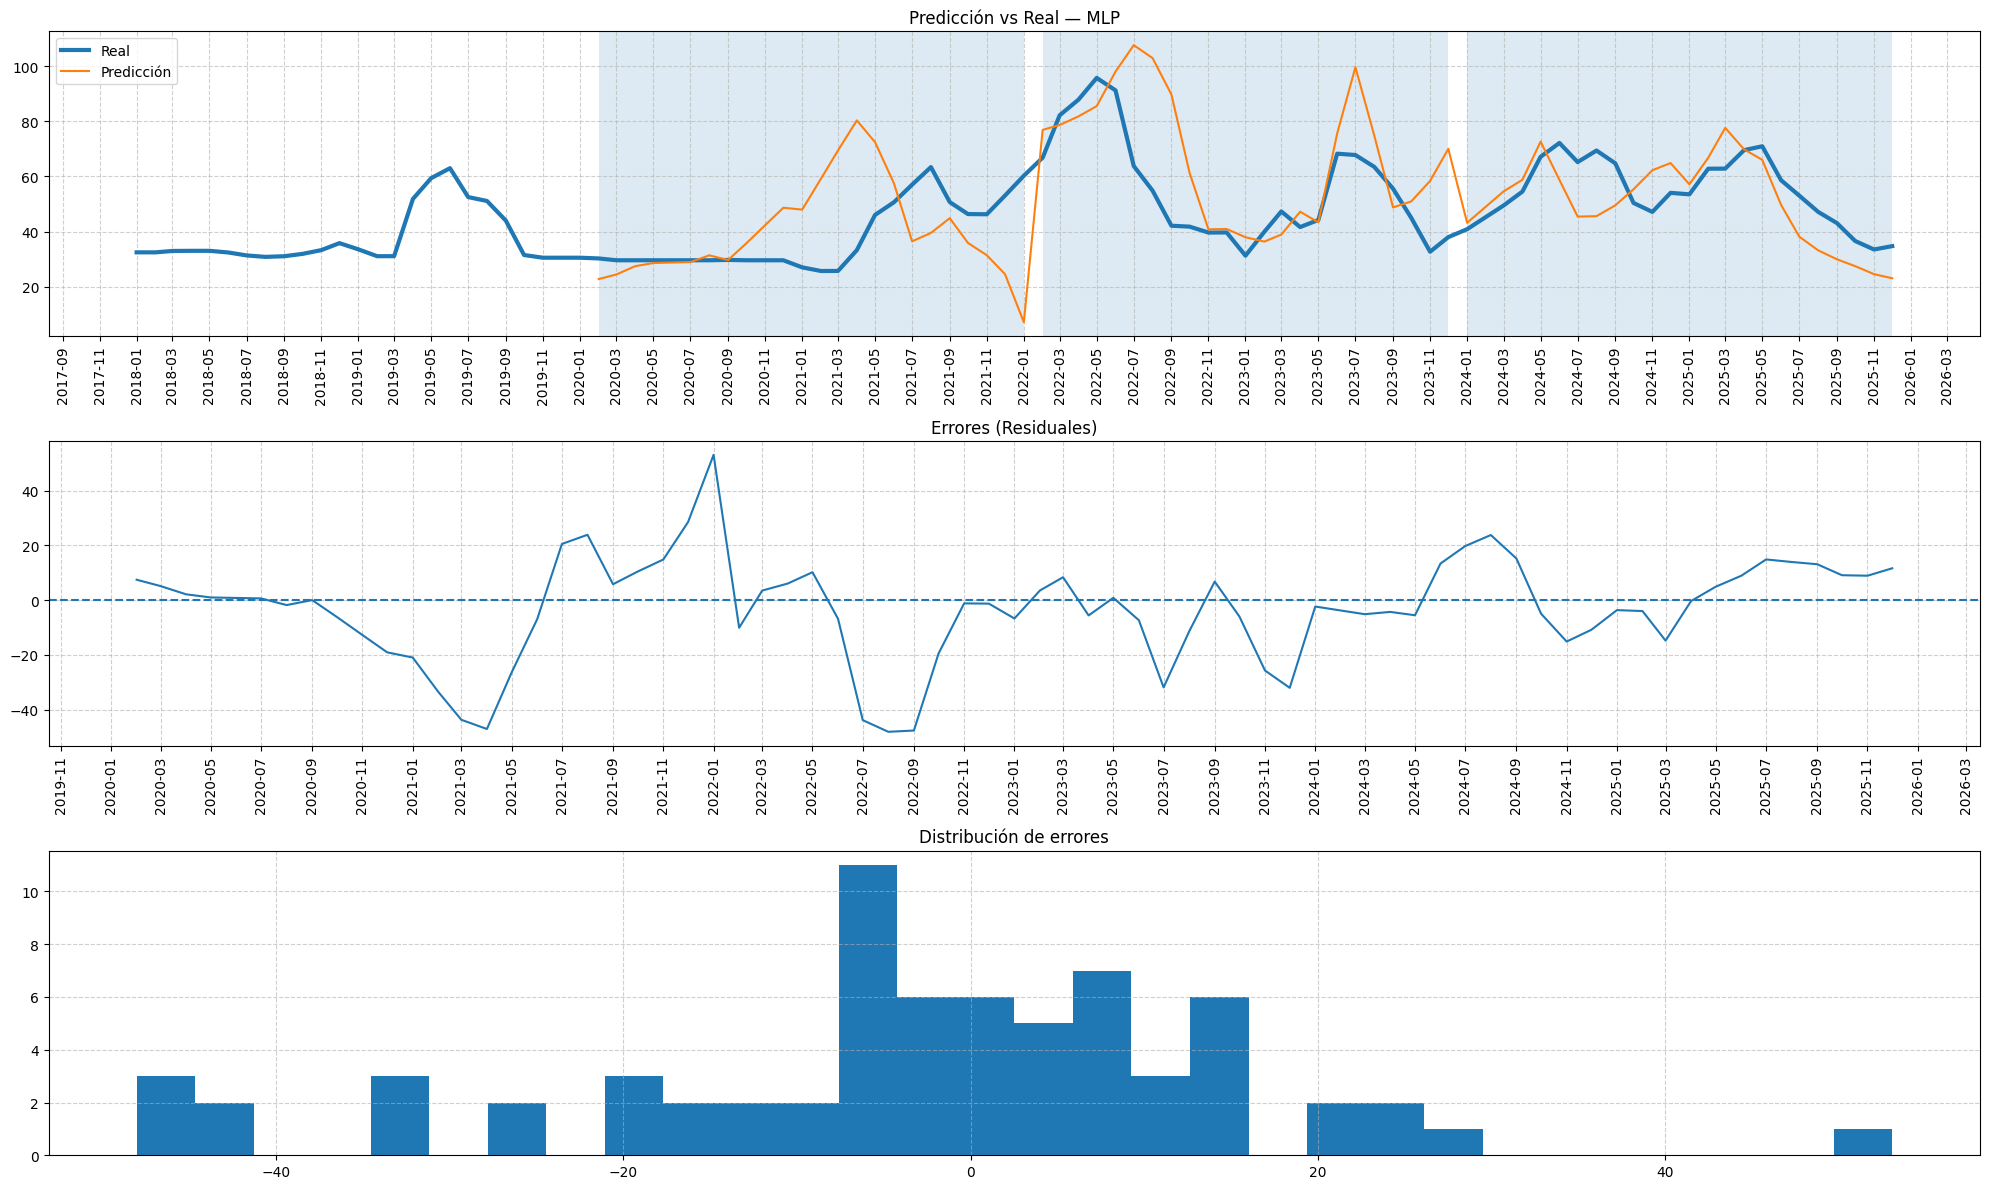


Modelo: ExtraTrees
MAE : 8.00
RMSE: 12.02
MAPE: 15.20%
MAPE Std: 11.33


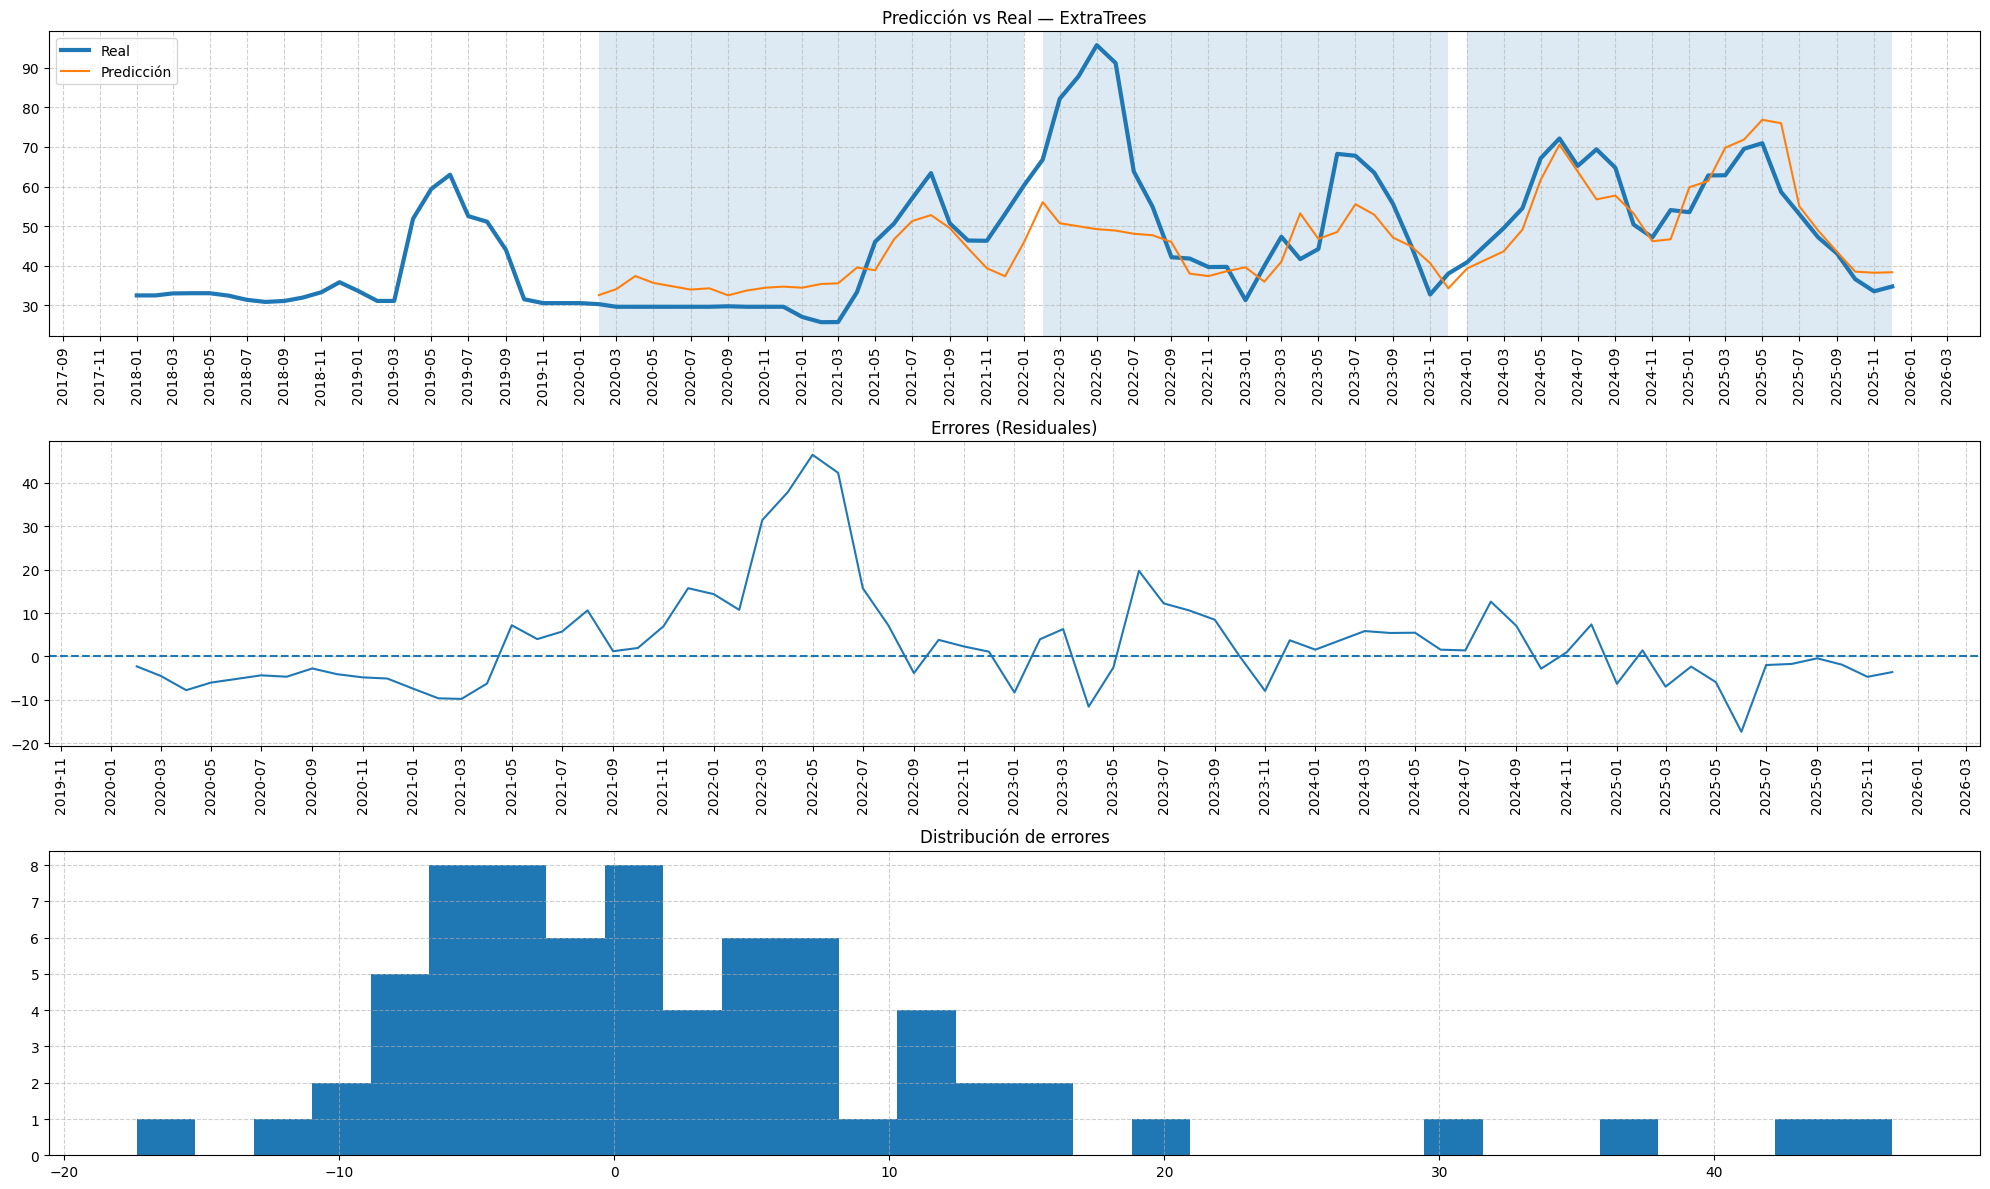


Modelo: LSTM
Usando secuencias para LSTM
MAE : 29.95
RMSE: 34.00
MAPE: 53.80%
MAPE Std: 20.78


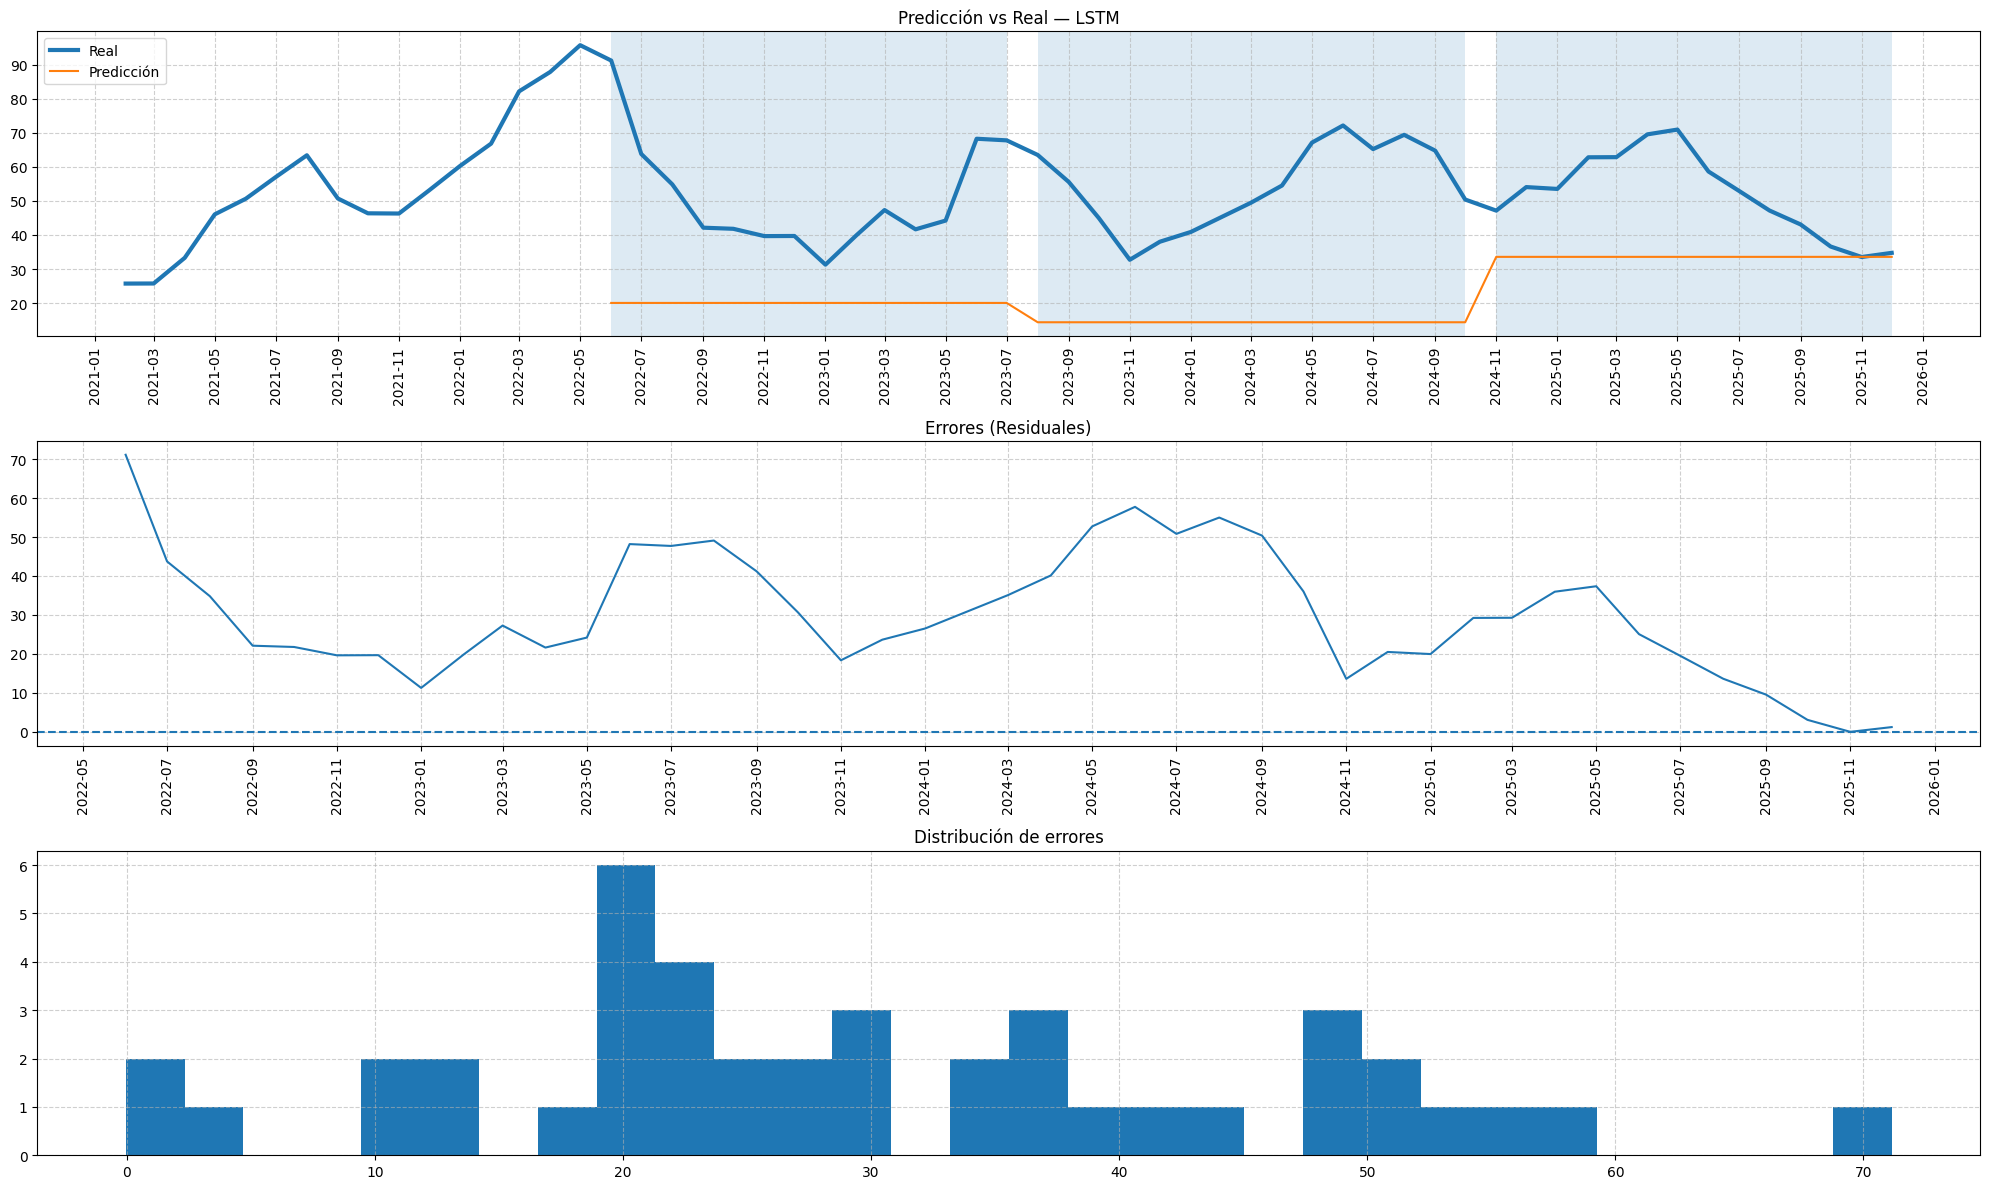

In [25]:
visualize_forecasting_models(models, X, y, tscv)

#13. Conclusiones


| Modelo | MAE | RMSE | MAPE | MAPE Std |
| :--- | :--- | :--- | :--- | :--- |
| ElasticNet (final) | 6.60 | 8.55 | 12.80% | - |
| ExtraTress | 8.44 | 11.06 |16.56% | 6.39 |
| GaissianProcess | 9.30 | 11.48 | 17.37% | 8.34 |
| SVR | 9.70 | 12.46 |17.80% | 7.71 |
| MLP | 13.88 | 18.23 | 31.63% | 9.30 |
| LSTM | 46.09 | 48.09 |94.10% | 1.61 |


Los resultados del análisis comparativo muestran que **ElasticNet continúa siendo el modelo con mejor desempeño predictivo** para la estimación del precio del aguacate en el conjunto de datos analizado. Este modelo obtuvo los errores más bajos en todas las métricas evaluadas, con un **MAE de 6.60**, **RMSE de 8.55** y **MAPE de 12.80%**, superando de forma consistente a los modelos alternativos evaluados.

Estos resultados refuerzan la idea de que, en **datasets de tamaño reducido (aproximadamente 97 observaciones)**, los modelos lineales regularizados tienden a ofrecer un mejor equilibrio entre **capacidad predictiva y generalización**. La regularización incorporada en ElasticNet permite controlar el sobreajuste, manteniendo al mismo tiempo una estructura relativamente simple e interpretable.

Por otra parte, los modelos basados en árboles y máquinas de soporte vectorial, como **ExtraTrees y SVR**, mostraron un desempeño intermedio, con errores de **MAE entre 8 y 10** y **MAPE cercanos al 17%**. Esto sugiere que estos métodos logran capturar cierta **no linealidad en los datos**, aunque dicha capacidad no se traduce en mejoras significativas en precisión frente al modelo lineal regularizado. En términos de estabilidad, la desviación estándar del MAPE indica que **ExtraTrees presenta una variabilidad ligeramente menor que SVR durante la validación cruzada**, lo que sugiere un comportamiento algo más consistente entre folds.

En contraste, los modelos de mayor complejidad, particularmente **MLP, LSTM y Gaussian Process**, presentaron errores considerablemente más altos. El modelo **LSTM** obtuvo el peor desempeño, con un **MAPE superior al 94%**, lo que indica una baja capacidad de generalización en el contexto del dataset utilizado. Aunque este modelo mostró una desviación estándar baja en el MAPE (1.61%), lo que sugiere errores consistentes entre particiones de validación, las predicciones generadas no resultan útiles para fines prácticos.

Este comportamiento es consistente con la literatura en aprendizaje automático, la cual indica que **los modelos de alta complejidad suelen requerir conjuntos de datos significativamente más grandes** para capturar patrones relevantes y evitar problemas de sobreajuste o inestabilidad en el entrenamiento.

En cuanto al modelo LSTM, uno de los objetivos de esta iteración fue mejorar su desempeño respecto a experimentos previos. Los resultados muestran que se logró una mejora considerable, reduciendo el error desde un MAPE de 94.10% en la configuración anterior hasta 53.80% en la versión actual. Esto indica que los ajustes realizados en el proceso de entrenamiento y en la preparación de las secuencias permitieron que el modelo capturara parcialmente mejor la dinámica temporal de la serie.

No obstante, esta mejora en el error medio viene acompañada de una mayor inestabilidad en las predicciones, reflejada en una desviación estándar del MAPE de 20.78. Este comportamiento sugiere que el modelo es altamente sensible a la partición de los datos en los distintos folds de validación temporal, lo que puede introducir variaciones importantes en su desempeño.

De manera similar, varios de los modelos evaluados presentan desviaciones estándar relativamente altas en el MAPE, como es el caso de SVR, Gaussian Process y MLP, lo que sugiere que el proceso de validación revela una variabilidad considerable en los errores dependiendo de la ventana temporal utilizada para entrenamiento y prueba. Este fenómeno es común en series de tiempo cortas y con alta volatilidad, donde pequeñas variaciones en los datos de entrenamiento pueden impactar significativamente la capacidad de generalización del modelo.

En resumen, los resultados obtenidos sugieren que, para la **predicción de precios del aguacate con series de tiempo limitadas**, los **modelos lineales regularizados como ElasticNet representan una alternativa eficiente, robusta e interpretable**. En contraste, la incorporación de modelos más complejos no solo no aporta mejoras en precisión bajo estas condiciones, sino que puede incluso deteriorar significativamente el desempeño predictivo.